## Procesamiento de los datos para Machine Learning
Aplicar las técnicas principales de procesamiento de datod para preparar un dataset antes del entrenamiento.


## Parte 1. Comprensión del problema 
Trabajaremos con el Dataset de Titanic, para construir un modelo que sea capaz de predecir si una persona sobrevive o no

In [2]:
import pandas as pd
import numpy as np

#Librerias de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

#Librerias para graficar
import seaborn as sns
import matplotlib.pyplot as plt

#Libreria de Kaggle
import kagglehub

C:\Users\Guadalupe\anaconda3\envs\Extracion9AVS\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os

# 1. Descargar el dataset del Titanic desde Kaggle
path = kagglehub.dataset_download("rahulsah06/titanic")
print("El dataset se descargó en:", path)

# 2. Cargar el archivo de entrenamiento (train.csv)
df = pd.read_csv(os.path.join(path, "train.csv"))

# 3. Mostrar las primeras 5 filas para comprobar que todo esté en orden
df.head()

El dataset se descargó en: C:\Users\Guadalupe\.cache\kagglehub\datasets\rahulsah06\titanic\versions\1


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Descargamos el Dataset de la pagina Kaggle
path = kagglehub.dataset_download("yasserh/titanic-dataset")
path 

'C:\\Users\\Guadalupe\\.cache\\kagglehub\\datasets\\yasserh\\titanic-dataset\\versions\\1'

In [5]:
### Creamos el Dataframe
dfTitanic = pd.read_csv(path + "/Titanic-Dataset.csv")

In [6]:
# Mostramos las primeras 5 filas
dfTitanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
dfTitanic.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

## Parte 2. Seleccion de Variables Predictoras y Variable Objetivo

La variable objetivo sera: Survived

donde 0 = No sobrevivio 1= Sobrevivio

In [8]:
dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [9]:
dfTitanic.groupby(
    "Sex"
)["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [10]:
dfTitanic.groupby(
    "Fare"
)["Survived"].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

## Parte 3. Correlacion e Hipótesis
vamos a identificar la relación entre variables numericas
Nota: La correlacion No representa la importancia Real de la variable en el modelo


In [11]:
variables_numericas = [
    "Survived",
    "Pclass",
    "SibSp",
    "Parch",
    "Fare"
]

In [12]:
corr = dfTitanic[variables_numericas].corr() #Creamos la matriz de correlacion
corr

,Survived,Pclass,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,0.083081,0.018443,-0.549500
SibSp,-0.035322,0.083081,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.159651,0.216225,1.000000


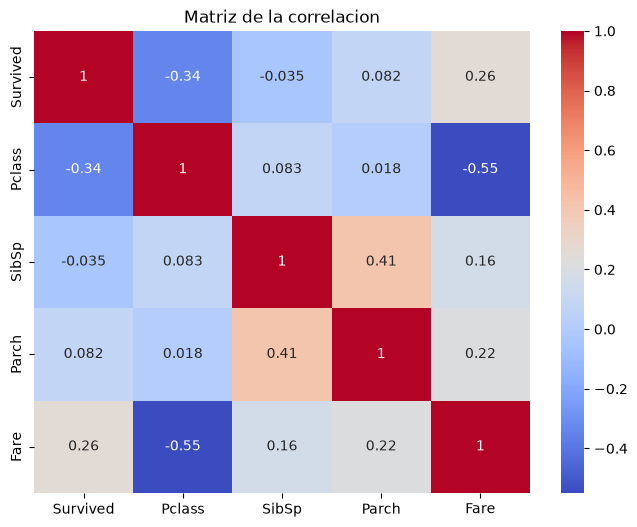

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de la correlacion")
plt.show()

## Parte 4. Variables predictoras.

x---> Aquellas variables que nos ayudan a predecir
y---> Variable objetivo

In [14]:
dfTitanic.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [15]:
columnas= [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked"
]


In [16]:
X = dfTitanic[columnas]
y = dfTitanic["Survived"]

In [17]:
X.columns

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked'], dtype='object')

In [18]:
y.name

'Survived'

## Parte 5. limpieza de los datos
Realizaremos la imputación de los datos, donde existan valores nulos

In [19]:
#Revisamos si existen valores nulos
X.isnull().sum()

Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
dtype: int64

In [20]:
#vamos a imputar los datos para el campo Edad, calculando la mediana
X["Age"] = X ["Age"].fillna(
    X["Age"].median() )

C:\Users\Guadalupe\AppData\Local\Temp\ipykernel_22992\1321771475.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Age"] = X ["Age"].fillna(


In [21]:
#Vamos imputar los datos para el campo Emberked, calculando la moda

X["Embarked"]= X["Embarked"].fillna(
    X["Embarked"].mode()[0]
)

C:\Users\Guadalupe\AppData\Local\Temp\ipykernel_22992\3510416700.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Embarked"]= X["Embarked"].fillna(


In [22]:
#Revisamos si existen valores nulos
X.isnull().sum()

Pclass      0
Sex         0
Age         0
Fare        0
Embarked    0
dtype: int64

## Parte 6. Normalizamos los datos categoricos(texto)
Los algoritmos de ML no entienden texto.

In [23]:
X.head(2)

,Pclass,Sex,Age,Fare,Embarked
0,3,male,22.0,7.2500,S
1,1,female,38.0,71.2833,C


In [24]:
#One hot Encoding
X = pd.get_dummies(
    X,
    columns=[
        "Sex",
        "Embarked"
    ],
    drop_first= True
)

In [25]:
X.head(2)

,Pclass,Age,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,7.2500,True,False,True
1,1,38.0,71.2833,False,False,False


## Parte 7. Division de los datos

No debemos entrenar y evaluar utilizando los mismos datos

80% para entrenar

20% para evaluar

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [27]:
print("Entrenamiento X: ", X_train.shape)

Entrenamiento X:  (712, 6)


In [28]:
print("Prueba X: ", X_test.shape)

Prueba X:  (179, 6)


In [29]:
print("Entrenamiento Y: ", y_train.shape)

Entrenamiento Y:  (712,)


In [30]:
print("Prueba y: ", y_test.shape)

Prueba y:  (179,)


 ## Escalado de los  datos
 Las variables  numericas tienen valores distintos. El escalado evita que las variables con mayores valores dominen el aprendizaje del modelo.

In [31]:
columnas_numericas = [
    "Age",
    "Fare",
    
]

In [32]:
X_train[columnas_numericas].describe()

,Age,Fare
count,712.000000,712.000000
mean,29.204129,32.586276
std,13.007971,51.969529
min,0.420000,0.000000
25%,22.000000,7.925000
50%,28.000000,14.454200
75%,35.000000,30.500000
max,80.000000,512.329200


In [33]:
X_train[columnas_numericas].describe()

,Age,Fare
count,712.000000,712.000000
mean,29.204129,32.586276
std,13.007971,51.969529
min,0.420000,0.000000
25%,22.000000,7.925000
50%,28.000000,14.454200
75%,35.000000,30.500000
max,80.000000,512.329200


In [34]:
#Escalamos los datos usando StandarScale
scaler = StandardScaler()

In [35]:
X_train[columnas_numericas]= scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

In [36]:
X_train[columnas_numericas].describe()

,Age,Fare
count,7.120000e+02,7.120000e+02
mean,1.746418e-17,5.363999e-17
std,1.000703e+00,1.000703e+00
min,-2.214363e+00,-6.274674e-01
25%,-5.542135e-01,-4.748670e-01
50%,-9.263364e-02,-3.491435e-01
75%,4.458762e-01,-4.017244e-02
max,3.907725e+00,9.237724e+00


## Entrenamiento del Algoritmo: Arbol de decision
Permite clasificar los registros con respecto a las variables

In [37]:
modelo = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

In [38]:
modelo.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

#Evaluamos la eficacia del modelo
Realizamos prediciones sobre el conjunto de prueba, para calcular la exactitud del modelo

In [39]:
#Invocamos el modelo, el metodo predict con los datos de prueba no vistos. 
prediccion = modelo.predict(
    X_test
)

In [40]:
pd.DataFrame(
    {
        "Survived Real: ": y_test,
        "Survived Predicha: ": prediccion
    }
).head(10)

,Survived Real:,Survived Predicha:
709,1,0
439,0,0
840,0,0
720,1,1
39,1,1
290,1,1
300,1,1
333,0,0
208,1,1
136,1,1


## Evaluacion del modelo 
Utilizaremos el acuracy para determinar el porcentaje de predicciones correctas realizadas por el modelo.

In [41]:
accuracy = accuracy_score(y_test,prediccion)

In [42]:
print(f"La exactitud del modelo es: {accuracy: .4}")

La exactitud del modelo es:  0.7989


In [43]:
from sklearn.metrics import classification_report

In [44]:
print(classification_report(y_test, prediccion))

              precision    recall  f1-score   support

           0       0.78      0.91      0.84       105
           1       0.84      0.64      0.72        74

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179

